# 8.10 텍스트 분석 실습 - 캐글 Mercari Price Suggestion Challenge

데이터 전처리

In [1]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

mercari_df= pd.read_csv('/content/mercari_train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)


(115805, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3.0,Men/Tops/T-shirts,NaN,10.0,1.0,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3.0,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0.0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1.0,Women/Tops & Blouses/Blouse,Target,10.0,1.0,Adorable top with a hint of lace and a key hol...


In [2]:
print(mercari_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115805 entries, 0 to 115804
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   train_id           115805 non-null  int64  
 1   name               115804 non-null  object 
 2   item_condition_id  115804 non-null  float64
 3   category_name      115328 non-null  object 
 4   brand_name         66069 non-null   object 
 5   price              115804 non-null  float64
 6   shipping           115804 non-null  float64
 7   item_description   115804 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 7.1+ MB
None


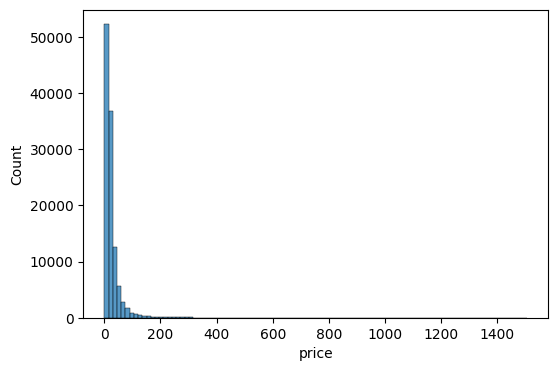

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_df = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df, bins=100)
plt.show()

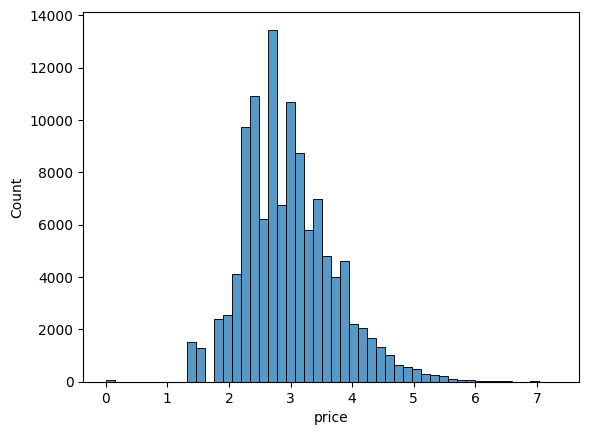

In [5]:
import numpy as np

y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

In [6]:
mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

,price
0,2.397895
1,3.970292
2,2.397895


In [7]:
print('Shipping 값 유형:\n', mercari_df['shipping'].value_counts())
print ('item_condition_id 값 유형: \n', mercari_df ['item_condition_id'].value_counts())


Shipping 값 유형:
 shipping
0.0    63944
1.0    51860
Name: count, dtype: int64
item_condition_id 값 유형: 
 item_condition_id
1.0    49959
3.0    33697
2.0    29467
4.0     2491
5.0      190
Name: count, dtype: int64


In [8]:
boolean_cond= mercari_df['item_description']== 'No description yet'
mercari_df[boolean_cond]['item_description'].count()

np.int64(6572)

In [10]:
# apply 1amda에서 호출되는 대, 중, 소 분할 함수 생성, 대, 중, 소 값을 리스트로 반환
def split_cat(category_name):
    try:
       return category_name.split('/')
    except:
       return ['Other_Null', '0ther_Null', 'Other_Null']

# 위의 split_cat( )을 apply lambda에서 호출해 대, 중, 소 칼럼을 mercari_df에 생성.
mercari_df ['cat_dae' ], mercari_df['cat_jung'], mercari_df ['cat_so'] = \
                        zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))

# 대분류만 값의 유형과 건수를 살펴보고, 중분류, 소분류는 값의 유형이 많으므로 분류 개수만 추출
print('대분류 유형 :\n', mercari_df['cat_dae'].value_counts())
print('중분류 개수 :', mercari_df[ 'cat_jung' ].nunique())
print('소분류 개수 :', mercari_df['cat_so'].nunique())

대분류 유형 :
 cat_dae
Women                     52050
Beauty                    16310
Kids                      13365
Electronics                9566
Men                        7259
Home                       5263
Vintage & Collectibles     3629
Other                      3528
Handmade                   2390
Sports & Outdoors          1968
Other_Null                  477
Name: count, dtype: int64
중분류 개수 : 112
소분류 개수 : 710


In [12]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category.name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')

# 각 칼럼별로 Null 값 건수 확인. 모두 0이 나와야 합니다.
mercari_df.isnull().sum()

,0
train_id,0
name,1
item_condition_id,1
category_name,477
brand_name,0
price,1
shipping,1
item_description,0
cat_dae,0
cat_jung,0


피처 인코딩과 피처 벡터화

In [13]:
print('brand name 의 유형 건수 :', mercari_df['brand_name'].nunique())
print('brand name sample 5건 : \n', mercari_df['brand_name'].value_counts()[:5])

brand name 의 유형 건수 : 2182
brand name sample 5건 : 
 brand_name
Other_Null           49736
PINK                  4291
Nike                  4188
Victoria's Secret     3694
LuLaRoe               2423
Name: count, dtype: int64


In [14]:
print('name 의 종류 개수 :', mercari_df['name'].nunique())
print('name sample 7건 : \n', mercari_df['name'][:7])

name 의 종류 개수 : 108366
name sample 7건 : 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


In [15]:
pd.set_option('max_colwidth', 200)

# item_description의 평균 문자열 크기
print ('item_description 평균 문자열 크기:', mercari_df['item_description'].str.len().mean())

mercari_df['item_description'][:2]

item_description 평균 문자열 크기: 145.57190967574803


,item_description
0,No description yet
1,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.


In [18]:
# name 속성에 대한 피처 벡터화 변환
mercari_df['name'] = mercari_df['name'].fillna(value='Other_Null')
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df.name)

# item_description에 대한 피처 벡터화 변환
tfidf_descp = TfidfVectorizer(max_features = 50000, ngram_range= (1, 3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

print('name vectorization shape：', X_name.shape)
print('item_description vectorization shape：', X_descp.shape)

name vectorization shape： (115805, 27371)
item_description vectorization shape： (115805, 50000)


In [22]:
from sklearn.preprocessing import LabelBinarizer

# Fill NaN values and convert to string type for consistency before LabelBinarizer
mercari_df['item_condition_id'] = mercari_df['item_condition_id'].fillna(value='Other_Null').astype(str)
mercari_df['shipping'] = mercari_df['shipping'].fillna(value='Other_Null').astype(str)

# brand-name, item_condition_id, shipping 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_brand_name= LabelBinarizer(sparse_output=True)

X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])
lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])
lb_shipping= LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

# cat_dae, cat Jung, cat_so 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae= lb_cat_dae.fit_transform(mercari_df['cat_dae'])
lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])
lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

In [23]:
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand shape：{0}, X_item_cond_id shape：{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape：{0}, X_cat_dae shape：{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape：{0}, X_cat_so shape：{1}'.format(X_cat_jung.shape, X_cat_so.shape))


<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape：(115805, 2182), X_item_cond_id shape：(115805, 6)
X_shipping shape：(115805, 3), X_cat_dae shape：(115805, 11)
X_cat_jung shape：(115805, 112), X_cat_so shape：(115805, 710)


In [25]:
from scipy.sparse import hstack
import gc

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# hstack 함수를 이용해 인코딩과 벡터화를 수행한 데이터 세트를 모두 결합.
X_features_sparse= hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)

# 데이터 세트가 메모리를 많이 차지하므로 사용 목적이 끝났으면 바로 메모리에서 삭제.
del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (115805, 80395)


1072

릿지 회귀 모델 구축 및 평가

In [37]:
def rmsle(y, y_pred):
   # underflow, overflow를 막기 위해 log가 아닌 log1p로 rmsle 계산
   return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))

def evaluate_org_price(y_test, preds):

    # 원본 데이터는 log1p로 변환되었으므로 expm1으로 원복 필요.
    preds_exmpm = np.expm1(preds)
    y_test_exmpm = np.expm1(y_test)

    # rmsle로 RMSLE 값 추출
    rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
    return rmsle_result

In [33]:
import gc
from scipy.sparse import hstack

def model_train_predict(model, matrix_list):
    # scipy.sparse 모듈의 hstack을 이용해 희소 행렬 결합
    X = hstack(matrix_list).tocsr()

    # Get the target variable (price) and filter out NaN values explicitly
    y_price = mercari_df['price']
    y_filtered = y_price.dropna()

    # Filter X using the indices from the NaN-free y_filtered
    X_filtered = X[y_filtered.index]

    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered,
                                                      test_size=0.2, random_state=156)

    # 모델 학습 및 예측
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    del X, X_train, X_test, y_train, X_filtered, y_filtered
    gc.collect()

    return preds, y_test

In [38]:
linear_model = Ridge(solver = "lsqr", fit_intercept=False)

sparse_matrix_list = (X_name, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle 값:', evaluate_org_price(y_test, linear_preds))

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 포함한 rmsle 값:', evaluate_org_price(y_test, linear_preds))

Item Description을 제외했을 때 rmsle 값: 0.5329292778396874
Item Description을 포함한 rmsle 값: 0.5178977996005748


LightGBM 회귀 모델 구축과 앙상블을 이용한 최종 예측 평가

In [39]:
from lightgbm import LGBMRegressor

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=156)
lgbm_preds, y_test = model_train_predict(model = lgbm_model, matrix_list=sparse_matrix_list)
print('LightGBM rmsle 값:', evaluate_org_price(y_test, lgbm_preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 31.459246 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 433269
[LightGBM] [Info] Number of data points in the train set: 92643, number of used features: 16643
[LightGBM] [Info] Start training from score 2.976850


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM rmsle 값: 0.5434679686390672


In [41]:
preds = lgbm_preds * 0.45 + linear_preds * 0.55
print('LightGBM과 Ridge를 ensemble한 최종 rmsle 값:',  evaluate_org_price(y_test, preds))

LightGBM과 Ridge를 ensemble한 최종 rmsle 값: 0.5011372297077332
